In [ ]:
import copy
import math
import gc
import glob
import logging
import multiprocessing
import operator
import os
import subprocess
import itertools
import tempfile
import time

import numpy as np
import pandas as pd
from tqdm import tqdm
from subprocess import Popen, PIPE

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import EnumerateStereoisomers
from rdkit.Chem import MolStandardize
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdMolAlign
from rdkit.ML.Cluster import Butina
from rdkit.Chem import DataStructs

OBABEL_PATH = "/chemotargets/shared/conda/envs/obabel/bin/obabel"
def obabel_protonate(mol, ph=7):
    """
    WARNING: DO NO NOT DISTRIBUTE THIS CODE.
    OpenBabel is under GPL license.
    DO NOT LINK DIRECTLY TO OBABEL LIBS

    NOT AVAILABLE IN RDKIT: USE BABEL EXECUTABLE
    Importing pybel and rdkit at the same time produces impredictive behaviour

    """

    cmd = [OBABEL_PATH, "-i mol", "-o mol"]

    if ph:
        cmd.append("-p {}".format(ph))

    p = Popen(" ".join(cmd), stdout=PIPE, stdin=PIPE, stderr=PIPE, shell=True)
    stdout, stderr = p.communicate(input=mol.encode('utf-8'))
    mol2 = stdout.decode('utf-8')
    return mol2


class Molecule(object):
    """
    Extends RDkit Mol class by composition """

    def __init__(self, mol=None):

        self._molecule = mol
        self.properties = {}

        if mol is not None:
            assert isinstance(mol, Chem.Mol)

        self.lines = None
        self._infile = None


    def __getattr__(self, attr):
        # Allows the class to be pickable avoiding RecursionError
        if attr == "molecule":
            raise AttributeError

        if attr == "_molecule":
            raise AttributeError

        return getattr(self.molecule, attr)

    def __setitem__(self, key, value):
        self.properties[key] = value
        if self.molecule is not None:
            self.molecule.SetProp(key, str(value))

    def __getitem__(self, key):
        try:
            return self.properties[key]
        except KeyError:
            return self.molecule.GetProp(key)

    def __delitem__(self, key):
        self.properties.remove(key)

    def __contains__(self, key):
        return key in self.properties

    def __str__(self):
        smiles = "NOT LOADED"
        if self.molecule:
            smiles = Chem.MolToSmiles(self.molecule)
        return "{} {}".format(self.__class__, smiles)

    @property
    def molecule(self):
        return self._molecule

    @molecule.setter
    def molecule(self, value):
        if value is not None:
            assert isinstance(value, Chem.rdchem.Mol)
        self._molecule = value

    @property
    def infile(self):
        return self._infile

    @infile.setter
    def infile(self, value):
        if value is not None:
            self._infile = value

    def get_molecule(self):
        return self.molecule

    def append(self, molecule):
        try:
            self.molecules.append(molecule)
        except AttributeError:
            self.molecules = [molecule]

    def get_properties(self):
        return self.properties

    def set_property(self, name, value):
        if name == "_Name":
            self.name = value
        self.properties[name] = value

    def keys(self):
        return self.properties.keys()

    def clear_properties(self):
        self.properties = {}
        for property in self.molecule.GetPropNames(includePrivate=True):
            self.molecule.ClearProp(property)

    def fix_charges(self):
        """
        Tries to fix unssigned charges
        Needs to have read the molecule with sanitize=False


        Based on:
        https://www.blopig.com/blog/2024/09/out-of-the-box-rdkit-valid-is-an-imperfect-metric-a-review-of-the-kekulizeexception-and-nitrogen-protonation-to-correct-this/
        """

        self.molecule.UpdatePropertyCache(strict=False)
        problems = Chem.DetectChemistryProblems(self.molecule)

        for problem in problems:

            if problem.GetType() =='AtomValenceException':

                atom = self.molecule.GetAtomWithIdx(problem.GetAtomIdx())

                if atom.GetAtomicNum() == 7 and atom.GetFormalCharge() == 0 and atom.GetExplicitValence() == 4:
                    atom.SetFormalCharge(1)

                if atom.GetAtomicNum() == 8 and atom.GetFormalCharge() == 0 and atom.GetExplicitValence() == 3:
                    atom.SetFormalCharge(1)

        Chem.SanitizeMol(self.molecule)

    def generate_conformers(self, n: int = 1,
                            rms: float = 0.5,
                            ref: bool = False,
                            seed: int = -1,
                            compute_energies: bool = False,
                            pH: int = 7,
                            fast: bool = False):
        """
        Generate conformers for the molecule.

        Args:
            n (int): Number of conformers to generate.
            rms (float): RMS threshold for conformer pruning.
            ref (bool): Flag indicating whether to add a reference conformer.
            seed (int): Random seed for conformer generation.
            compute_energies (bool): Flag indicating whether to compute conformer energies.
            fast (int): If true does NOT optimize conformer energies.

        Returns:
            conformers (list): List[Molecule] of generated conformers.
        """

        mol = self.molecule

        # Protonate
        if pH is not None:
            mol = Molecule(self.protonate(pH)).molecule

        # Adding Explicit Hydrogens
        mol = Chem.AddHs(mol, addCoords=True)
        refmol = Chem.AddHs(Chem.Mol(mol))

        # Generate conformers using RDKit
        param = rdDistGeom.ETKDGv2()
        param.randomSeed = seed
        param.pruneRmsThresh = rms
        param.maxAttempts = 500
        param.enforceChirality = True
        cids = rdDistGeom.EmbedMultipleConfs(mol=mol, numConfs=n, params=param)

        # No conformers coud be generated
        if len(cids) == 0:
            return []

        # Energy Optimization of each conformer
        if not fast:

            mp = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94s")
            AllChem.MMFFOptimizeMoleculeConfs(mol, numThreads=1, mmffVariant='MMFF94s')
            rdMolAlign.AlignMolConformers(mol)

            # Prunning conformers after energy minimization

            selected = [cids[0]]
            for i, cid in enumerate(cids[1:]):
                j = i+1
                min_rmsd = []
                while j < len(cids):
                    # maxMatches kept low to keep running time reasonable.
                    bestrmsd = AllChem.GetBestRMS(mol, mol,  cids[i], cids[j], maxMatches=1000)
                    min_rmsd.append(bestrmsd)
                    j += 1
                    if bestrmsd < rms:
                        break
                if min(min_rmsd) > rms:
                    selected.append(cid)

            cids = selected

        # Split conformers in molecules

        conformers = []

        if ref:
            # Add reference conformer
            refmol.SetProp("_Name", self.name if self.name else "")
            refmol.SetProp("CID", "-1")
            refmol.SetProp("Energy", "")
            conformers.append(Molecule(refmol))

        if compute_energies:

            # Calculate energies sequentially
            energy = {}
            for cid in cids:
                e = self.calculate_energy(mol, mp, cid)
                energy[cid] = e

            sorted_cids = sorted(energy, key=energy.get)

            # Add conformers with energies
            for cid in sorted_cids:
                m = Chem.Mol(refmol, True)
                m.AddConformer(mol.GetConformer(cid))
                m = Molecule(m)
                m.set_properties(self.get_properties())
                m.name = self.name if self.name else ""
                m["CID"] = str(cid)
                m["Energy"] = str(energy[cid])
                conformers.append(m)
        else:
            # Add conformers without energies
            for cid in cids:
                m = Chem.Mol(refmol, True)
                m.AddConformer(mol.GetConformer(cid))
                m = Molecule(m)
                m.set_properties(self.get_properties())
                m.name = self.name if self.name else ""
                m["CID"] = str(cid)
                m.set_properties()
                conformers.append(m)

        return conformers

    def calculate_energy(self, mol, mp, cid):
        """
        Calculate the energy of a conformer using MMFF force field.

        Args:
            mol (Molecule): The molecule object.
            mp: The molecule properties object.
            cid (int): Conformer ID.

        Returns:
            energy (float): The calculated energy.
        """
        ff = AllChem.MMFFGetMoleculeForceField(mol, mp, confId=cid)
        return ff.CalcEnergy()



    def get_conformer(self, nconf=0):
        return self.GetConformer(nconf)

    def cluster_conformers(self, threshold=0.5, prune=False):

        dmat = AllChem.GetConformerRMSMatrix(self.molecule, prealigned=False)
        clusters = Butina.ClusterData(dmat, self.molecule.GetNumConformers(), threshold, isDistData=True, reordering=True)

        if not prune:
            return clusters

        else:
            cid = [x[0] for x in clusters]
            m = Chem.Mol(self.molecule, True)
            m.SetProp("_Name", self.name)

            for conformer in self.GetConformers():
                if conformer.GetId() not in cid:
                    continue
                m.AddConformer(conformer, assignId=True)

        return m


    @property
    def name(self):
        try:
            return self["_Name"]
        except KeyError:
            return

    @name.setter
    def name(self, name):
        self["_Name"] = name

    def set_properties(self, properties=None):

        if properties:
            self.properties = copy.deepcopy(properties)

        # Set properties
        self.properties.update({k: self.molecule.GetProp(k) for
                                k in self.molecule.GetPropNames(includePrivate=True) if
                                k not in self.properties})

        # Set name
        try:
            self.properties["_Name"] = self.molecule.GetProp("_Name")
        except KeyError:
            pass

        for key, value in self.properties.items():
            if key not in self.molecule.GetPropNames(includePrivate=True):
                self.molecule.SetProp(key,  str(value))
    def get_atom_fpt(self, niter=8):

        fpt = {}
        for atom in self.GetAtoms():
            fpt[atom.GetIdx()] = self.get_atom_fpt_by_atom(atom, niter=niter)

        return fpt

    def get_atom_fpt_by_atom(self, atom, niter=8):

        seen = set([atom.GetIdx()])
        current = [atom.GetIdx()]
        fpt = []

        for i in range(niter):

            fpt.append("".join(sorted([self.GetAtomWithIdx(x).GetSymbol() for x in current])))

            seen.update(current)

            current = [self.GetAtomWithIdx(x).GetNeighbors() for x in current]
            current = set([a.GetIdx() for neigh in current for a in neigh if a.GetIdx() not in seen])

        return ".".join([x for x in fpt if x])

    def get_substructure_rms(self, molecule, mcs=None):

        if mcs is None:
            mcs = rdFMCS.FindMCS([self.molecule, molecule.molecule], completeRingsOnly=True)
        pattern = Chem.MolFromSmarts(mcs.smartsString)

        a = Molecule(self.get_fragment_by_pattern(pattern))
        b = Molecule(molecule.get_fragment_by_pattern(pattern))

        rmsd = a.rmsd(b)
        return rmsd

    def get_fragment_by_pattern(self, pattern):

        core = Chem.ReplaceSidechains(self.molecule, pattern)

        for b in core.GetBonds():
            if b.GetBeginAtom().GetAtomicNum() == 0 and b.GetEndAtom().GetAtomicNum() == 0:
                core = Chem.RWMol(core)
                core.RemoveBond(b.GetBeginAtom().GetIdx(), b.GetEndAtom().GetIdx())
            elif b.GetBeginAtom().GetAtomicNum() == 0 or b.GetEndAtom().GetAtomicNum() == 0:
                b.SetBondType(Chem.BondType.SINGLE)
                b.SetIsAromatic(False)

        for a in core.GetAtoms():
            if (not a.IsInRing()):
                a.SetIsAromatic(False)
            if a.GetAtomicNum() == 0:
                a.SetAtomicNum(1)
                a.SetIsotope(0)
                a.SetIsAromatic(False)

        core = Chem.RemoveHs(core)

        return core

    def rmsd(self, reference, returnMatch=False):

        rmsd = Chem.rdMolAlign.CalcRMS(self.molecule,
                                       reference.molecule,
                                       symmetrizeConjugatedTerminalGroups=True)

        # Try uncharging the molecule
        if not rmsd:

            one = self.uncharge()
            other = reference.uncharge()

            rmsd = Chem.rdMolAlign.CalcRMS(one.molecule, other.molecule,
                                           symmetrizeConjugatedTerminalGroups=True)

        return rmsd

    def rmsd_advanced(self, reference, rdkit=True, returnMatch=False, max_tries=1000000):

        if rdkit:
            mapping = self.get_atom_mapping_rdkit(reference)
        else:
            mapping = self.get_atom_mapping_fingerprints(reference, max_tries=max_tries)

        rmsd, mappingBest = self.get_rmsd_for_mapping(reference, mapping)

        if returnMatch:
            return rmsd, mappingBest

        return rmsd

    def get_rmsd_for_mapping(self, reference, mapping):

        if not mapping:
            return None, None

        RMS = []
        for match in mapping:
            rms = 0
            for i, atom in enumerate(reference.GetAtoms()):

                pos1 = self.molecule.GetConformer(0).GetAtomPosition(match[atom.GetIdx()])
                pos2 = reference.GetConformer(0).GetAtomPosition(atom.GetIdx())

                p1 = np.array([pos1.x, pos1.y, pos1.z])
                p2 = np.array([pos2.x, pos2.y, pos2.z])

                rms += np.sum((p1-p2) ** 2)

            rms = math.sqrt(rms/reference.GetNumAtoms())
            RMS.append(rms)

        return min(RMS), mapping[np.argmin(np.array(RMS))]
    def get_atom_mapping_rdkit(self, reference):
        """
        Get atom mapping between two molecules using rdkit substructure matching
        """

        try:

            matches = self.molecule.GetSubstructMatches(reference.molecule,
                                                        uniquify=False,
                                                        useChirality=False,
                                                        useQueryQueryMatches=True)
        except Exception:
            return

        # Try uncharging the molecule
        if not matches:
            one = self.uncharge()
            other = reference.uncharge()
            try:
                matches = one.molecule.GetSubstructMatches(other.molecule,
                                                           uniquify=False,
                                                           useChirality=False,
                                                           useQueryQueryMatches=True)
            except Exception:
                return


        return matches

    def get_atom_mapping_fingerprints(self, reference, max_tries=1000000):

        fptref = self.get_atom_fpt(niter=8)
        fpt = reference.get_atom_fpt(niter=8)

        pairs = []
        for atom in self.GetAtoms():
            idx = atom.GetIdx()
            pairs.append([x for x in fptref if fptref[x] == fpt[idx]])

        matches = []
        for i, match in enumerate(itertools.product(*pairs)):

            if i > max_tries:
                break

            if len(set(match)) == len(match):
                matches.append(match)

        return matches

    def enumerate_tautomers(self, score=False, sort:bool=False):
        """ Enumerate tautomers """

        enumerator = MolStandardize.rdMolStandardize.TautomerEnumerator()
        tautomers = [Molecule(m) for m in enumerator.Enumerate(self.molecule)]
        [m.set_properties() for m in tautomers]

        if score:

            for tautomer in tautomers:
                score = enumerator.ScoreTautomer(tautomer.molecule)
                tautomer["tautomer_score"] = score

            tautomers.sort(key=lambda mol: float(mol["tautomer_score"]), reverse=True)

        return tautomers

    def enumerate_stereoisomers(self):


        Chem.FindMolChiralCenters(self.molecule, includeUnassigned=True)

        options = EnumerateStereoisomers.StereoEnumerationOptions(unique=False)
        isomers = [Molecule(m) for m in EnumerateStereoisomers.EnumerateStereoisomers(self.molecule, options=options)]

        # Setting parent properties
        [m.set_properties(self.get_properties()) for m in isomers]
        return isomers

    def count_charged_atoms(self) -> int:
        """
        Counts the number of charged atoms in a molecule.
        """
        return sum([1 for at in self.GetAtoms() if at.GetFormalCharge() != 0])

    def check_protonation(self):
        """
        Check for unrealistic overprotonation """

        # Number of charged atoms <= 3
        if self.count_charged_atoms() > 3:
            return False

        # Net Charge [-1, 0, 1]
        if Chem.GetFormalCharge(self.molecule) not in [-1, 0, 1]:
            return False

        return True

    def protonate(self, ph: int = 7):

        mol = obabel_protonate(Chem.MolToMolBlock(self.molecule), ph=ph)
        m = Chem.MolFromMolBlock(mol, sanitize=True)

        # Openbabel tends to overprotonate.
        # Discard compounds with multiple charges

        if m is None or Molecule(m).check_protonation() is False:
            return self.molecule
        return m



class Molecules:
    """
    Manages a list of molecules (Molecule) """

    def __init__(self, infile=None, molecules=None, name=None, read=False,
                 rdkit=True, removeHs=True, sanitize=True,
                 format="sdf", **kwargs):

        self.name = name
        self.molecules = molecules
        self.infile = infile
        self.sanitize = sanitize
        self.removeHs = removeHs
        self.format = format
        config =  {
            "smiles_separator": "\t",
            "smiles_header": True,
            "format_file_extensions": {
                "sdf": [".sdf", ".sd"],
                "smi": [".smi", ".smiles"]}}

        self.config = copy.deepcopy(config)
        self.rdkit = rdkit

        self.config.update(kwargs)

        self.size = None
        self.modified = False

        self.index = None
        self._iter = None

        # Convert rdkit.Chem to Molecule
        if molecules is not None:
            self.molecules = [Molecule(x) if isinstance(x, Chem.Mol)
                              else x for x in molecules]

        if read:
            self.load()

        self.operators = {
            "==": operator.eq,
            "<": operator.lt,
            "<=": operator.le,
            ">": operator.gt,
            ">=": operator.ge,
        }


        self._mfpgen = None

    def __repr__(self):

        info = [
            str(self.__class__),
        ]

        if self.infile:
            info.append(f"INFILE:\t{os.path.abspath(self.infile)}")

        info.append(f"SIZE:\t{len(self)}")

        info.append(f"READ:\t{self.molecules is not None}")

        return "\n".join(info)

    def __len__(self):

        if self.molecules is not None:
            return len(self.molecules)

        elif self._iter:
            try:
                return len(self._iter)
            except TypeError:
                # Estimate from sdf
                grep = subprocess.Popen(["egrep", "-c",  r'^\${4}', self.infile], stdout=subprocess.PIPE, shell=False)
                stdout, stderr = grep.communicate()
                try:
                    return int(stdout)
                except ValueError:
                    return 0
        else:
            self.set_iter(rdkit=self.rdkit)
            return len(self)

    def __getitem__(self, idx):
        self.load()
        return self.molecules[idx]

    def __iter__(self):

        if self.molecules is not None:
            for mol in self.molecules:
                if not mol.molecule and self.rdkit:
                    mol.load_from_molBlock()
                yield mol
            return

        elif self._iter is None:
            self.set_iter(rdkit=self.rdkit)

        if self._iter is not None and self.molecules is None:
            for mol in self._iter:
                if mol:
                    if self.rdkit:
                        m = Molecule(mol)
                        m.set_properties()
                        yield m
                    else:
                        yield mol

        # Reset the iterator after all molecules have been iterated
        self.reset()

    def set_iter(self, rdkit=True):
        """
        Set iterator for molecules.

        If rdkit is true uses rdkit Suppliers, otherwise treats molecules as
        text lines """

        if self._iter:
            return

        if self.molecules is not None:
            self._iter = self.iter_molecules(rdkit=rdkit)
            return

        if self.infile is None:
            return

        extension = os.path.splitext(self.get_infile())[-1]

        if rdkit is True:


            if extension in (".sdf", ".sd"):
                self._iter = Chem.ForwardSDMolSupplier(self.get_infile(),
                                                       sanitize=self.sanitize,
                                                       removeHs=self.removeHs)

            if extension in (".smi"):
                self._iter = Chem.SmilesMolSupplier(self.get_infile(),
                                                    delimiter=self.config["smiles_separator"],
                                                    titleLine=self.config["smiles_header"])
        else:

            if extension in (".sdf", ".sd"):
                self._iter = self.iter_sdf()
            if extension in (".smi"):
                self._iter = self.iter_smi()
    def fix_charges(self):
        for _ in self.fix_charges_generator():
            pass

    def fix_charges_generator(self):
        for m in self:
            m.fix_charges()
            yield m

    def read(self, infile):
        self.infile = infile
        self.load()

    def load(self, sanitize=None):

        if sanitize is not None:
            self.sanitize = sanitize

        if self.molecules is None:
            self.molecules = [m for m in self]
            [m.set_properties() for m in self]

    def get_infile(self):
        return self.infile

    def from_dataframe(self, df, molName="mol", name="_Name", fields=[],
                       rdkit=False):
        """ Load molecules from a Pandas DataFrame """


        self.molecules = []
        for i, row in df.iterrows():

            if rdkit:
                m = Molecule(row[molName])
            else:
                m = row[molName]

            m.clear_properties()

            m.clear_properties()
            m.name = row[name]

            for field in fields:
                m[field] = row[field]

            m.set_properties()

            self.molecules.append(m)

    def dataframe(self):
        """
        Create a df with mol properties.

        Only fields of the first molecule are used
        """

        data = []

        for i, mol in enumerate(self):

            mol.set_properties()

            if i == 0:
                columns = list(mol.get_properties().keys())

            # If field not in molecule properties use NAN
            data.append([mol.properties.get(x, np.nan) for x in columns] + [mol.molecule])

        df = pd.DataFrame(data, columns=columns + ["mol"])

        return df


    def write_sdf(self, outfile):
        w = Chem.SDWriter(outfile)
        for mol in self:
            try:
                mol.set_properties()
                w.write(mol.molecule)
            except: continue
        w.flush()


    def reset(self, rdkit=None):

        if rdkit is not None:
            self.rdkit = rdkit

        self._iter = None
        self.set_iter(rdkit=self.rdkit)



    def split(self, n=10, files=False, overwrite=False,
              generator=False, output_dir=".", format_=None, size=None):

        if format_ is None:
            if self.infile:
                format_ = self.infile.split(".")[-1]
            else:
                format_ = "sdf"

        if not os.path.isdir(output_dir):
            raise IOError(f"Output path {output_dir} doesn't exist.")

        # If molecules already loaded and no files needed
        if self.molecules is not None and files is False:
            return [ x for x in np.array_split(self.molecules, n) if x.size > 0]

        splitgen = self.split_generator(n=n, files=files,
                                        output_dir=output_dir,
                                        format_=format_,
                                        size=size)

        if generator:
            return splitgen

        return list(splitgen)

    def split_generator(self, n=10, files=False, output_dir=".",
                        format_="sdf", read=True, size=None):
        """
        Split molecules in chunks """

        if n is not None:
            size = len(self)
            chunk_size = math.ceil(size / n)
        else:
            chunk_size = size

        i = 0
        ichunk = 0

        for imol, mol in enumerate(self):

            if n == -1:
                ftmp = open(os.path.join(output_dir,"{}.sdf".format(mol.get_name())), "w")

                if format_ == "sdf":
                    w = Chem.SDWriter(ftmp)
                elif format_ == "smi":
                    w = self.get_smiles_writer(ftmp)

                w.write(mol.molecule)
                w.flush()
                ftmp.close()
                continue

            if i == chunk_size or imol == 0:

                if imol != 0:
                    w.close()
                    ftmp.close()
                    yield ftmp.name

                if files is True:
                    ftmp = open(os.path.join(output_dir, "{1}.{0:03d}.{2}".format(ichunk, os.path.splitext(
                        os.path.basename(self.infile))[0], format_)), "w")

                else:
                    ftmp = tempfile.NamedTemporaryFile("w",
                                                    dir=output_dir,
                                                    delete=False,
                                                    suffix=".{:03d}.sdf".format(ichunk))

                    # Reopen as regular file to avoid error. Bug in tempfile ?
                    ftmp2 = open(ftmp.name, "w")
                    ftmp.close()
                    ftmp = ftmp2


                if format_ == "sdf":
                    if self.rdkit:
                        w = Chem.SDWriter(ftmp)
                    else:
                        w = open(ftmp.name, "w")

                elif format_ == "smi":
                    w = self.get_smiles_writer(ftmp)

                i = 0
                ichunk += 1

            if self.rdkit:
                w.write(mol.molecule)
            else:
                w.writelines(mol.lines)

            i += 1

        if i > 0:
            w.close()
            yield ftmp.name

    def multiprocess(self, function, nsplits=None, size=None, ncpus=1,
                     format_="sdf",
                     outfile=None,
                     kwargs={},
                     clean=True,
                     external=False):
        """
        Execute molecules methods in parallel.

        It splits the molecule set, executes the function in each split and
        joins all the results.

        It is file based and uses a temporary folder in /tmp

        """

        if nsplits is None and size is None:
            nsplits = ncpus

        if outfile is None:
            outfile = "{}.{}.sdf".format(
                os.path.splitext(os.path.basename(self.infile))[0],
                function.__name__)

        # Skip Multiprocessing if ncpus and nsplits = 1
        if ncpus == 1 and nsplits == 1:
            kwargs["outfile"] = outfile
            if external is True:
                kwargs["molecules"] = self
            return function(**kwargs)

        # Callback functions

        def task_failed(result, chunk):
            self.logger.error(f"Error for chunk ({chunk}):{result}")

        def task_completed(result, chunk):
            #print(result)
            #self.logger.info(f"Task completed for chunk: {chunk}")
            pass

        # Create temporary folder
        with tempfile.TemporaryDirectory(prefix=f"molecules.{function.__name__}.",
                                         # delete=clean # Only available in
                                         # python >= 3.12
                                         ) as basepath:

            output_files = []

            # If ncpus = 1, use ThreadPool instead of Pool to allow
            # parallelization inside the function. Nested Pools can not exist

            if ncpus > 1:
                Pool = multiprocessing.Pool
            elif ncpus == 1:
                Pool = multiprocessing.pool.ThreadPool

            try:
                with Pool(ncpus) as pool:

                    for i, chunk in enumerate(self.split(
                        n=nsplits, size=size, files=True, generator=True,
                        overwrite=True, format_=format_,
                        output_dir=basepath)):

                        output_file = os.path.join(basepath, f"output_{i}.{format_}")
                        output_files.append(output_file)

                        molecules = Molecules(infile=chunk)

                        if external is False:
                            function = getattr(molecules, function.__name__)
                        else:
                            kwargs["molecules"] = molecules

                        res = pool.apply_async(function,
                                               kwds={**kwargs, "outfile": output_file},
                                               callback=lambda result, c=chunk: task_completed(result, c),
                                               error_callback=lambda result, c=chunk: task_failed(result, c))
                    # Close the pool
                    pool.close()

                    # Progress Bar waiting for all the tasks to be completed.
                    with tqdm(total=nsplits, desc=f"Molecule Multiprocessing ({function.__name__})") as pbar:
                        while pool._state == 'RUN' or pool._cache:
                            pbar.n = len(glob.glob(os.path.join(basepath, "output_*")))
                            pbar.refresh()
                            time.sleep(1)

                    # Wait for all tasks to complete. Should already be done
                    pool.join()

            finally:
                # The whole temprary folder is removed at the end
                #remove chunk files
                #[os.remove(fname) for fname in chunk_files]
                logging.info('MERGING FILES')
                with open(outfile, 'w',encoding='utf-8') as f:
                    for i, fname in enumerate(output_files):
                        if os.path.isfile(fname):
                            with open(fname) as infile:
                                # For smiles skip the header in all but
                                # the first file.
                                if format_ == "smi" and i > 0:
                                    infile.readline()
                                f.write(infile.read())
                            #os.remove(fname)
                gc.collect()

    def sort(self, key_, numeric=False, reverse=False):

        self.load()

        foo = lambda m: m[key_]
        if numeric:
            foo = lambda m: float(m[key_])

        self.molecules.sort(key=foo, reverse=reverse)

    def get_atom_fpt(self, atom, niter=6):

        seen = set([atom.GetIdx()])
        current = [atom.GetIdx()]
        fpt = ""

        for i in range(niter):

            fpt += "".join(sorted([self.GetAtomWithIdx(x).GetSymbol() for x in current]))
            seen.update(current)

            current = [self.GetAtomWithIdx(x).GetNeighbors() for x in current]
            current = set([a.GetIdx() for neigh in current for a in neigh if a.GetIdx() not in seen])

        return fpt

    def standardize(self, outfile=None, **kwargs):


        self.modified = True
        standardizer = MolStandardize.Standardizer()

        if outfile is not None:
            w = self.get_writer(outfile)

        for m in self:
            std = m.standardize(standardizer, **kwargs)
            if outfile is not None and std is not None:
                w.write(std)

        if self.molecules:
            self.molecules = [m for m in self.molecules if m.molecule is not None]
        return self.molecules

    def standardize_iter(self, **kwargs):

        standardizer = MolStandardize.Standardizer()

        for m in self:
            m.standardize(standardizer, **kwargs)
            yield m

    def enumerate(self, start=1, inplace=False, key="num"):

        if not inplace:
            for i, mol in enumerate(self):
                mol[key] = f"# {i+start:d}"
                yield mol
        else:
            self.load()
            for i, mol in enumerate(self):
                mol[key] = f"# {i+start:d}"
            return

    def prepare(self,
                conformers: bool = True,
                tautomers: bool = False,
                stereoisomers: bool = True,
                standardize: bool = True,
                nconf: int = 10,
                ref: bool = False,
                compute_energies: bool = False,
                pH: int = 7.4,
                outfile: str = None,
                seed: int = -1,
                fastconf: bool = False,
                maxtautomers: int = 10,
                maxstereoisomers: int = 10):
        """
        Prepare a set of molecules by generating tautomers, stereoisomers,
        and conformers as specified.

        Parameters:

            - conformers (bool, optional): Whether to generate conformers for
            each molecule. Default is True.

            - tautomers (bool, optional): Whether to generate tautomers for
            each molecule. Default is False.

            - stereoisomers (bool, optional): Whether to generate stereoisomers
            for each molecule. Default is True.

            - nconf (int, optional): Number of conformers to generate for
            each molecule if conformers is True. Default is 1.

            - ref (bool, optional): Whether to use reference conformers.
            Default is False.

            - compute_energies (bool, optional): Whether to compute energies
            for each conformer. Default is False.

            - pH (int, optional): pH value to consider during conformer
            generation. Default is 7.

            - output (str, optional): Path to the output file to save the
            processed molecules in SDF format.
            If None, the file is not written. Default is None.

            - fastconf: Skip energy optimization when generating conformers

        Returns:
        str or None: Path to the output file if specified and written
        successfully, otherwise None.

        Raises:
        IOError: If there is an error writing the output file.
        """

        # Need to load in memory as some molecule transformations are done
        # in place.

        self.load()
        self.logger.info(f"Preparing {len(self)} Molecules")

        try:
            tmp_mols = self

            if standardize:
                tmp_mols.standardize()
                self.logger.info(f"Molecules after Standardization: {len(tmp_mols)}")

            if tautomers:

                new_mols = Molecules(molecules=[])

                for m in tmp_mols:

                    try:
                        tautomer_molecules = m.enumerate_tautomers(score=True)
                    except Exception as e:
                        self.logger.warning(e)
                        tautomer_molecules =  [m]

                    # Sort by similarity to starting molecule
                    fp = AllChem.GetMorganFingerprint(m.molecule, 2)
                    tautomer_molecules.sort(key=lambda x: DataStructs.TanimotoSimilarity(fp,
                        AllChem.GetMorganFingerprint(x.molecule, 2)), reverse=True)

                    interval = len(tautomer_molecules) // maxtautomers
                    if interval > 0:
                        new_mols.extend(tautomer_molecules[::interval])
                    else:
                        new_mols.extend(tautomer_molecules)


                tmp_mols = new_mols
                self.logger.info(f"Molecules after Tautomer Enumeration: {len(tmp_mols)}")

            if stereoisomers:
                tmp_mols = Molecules(molecules=[stereoisomer for m in tmp_mols for stereoisomer in m.enumerate_stereoisomers()])
                self.logger.info(f"Molecules after Stereoisomer Enumeration: {len(tmp_mols)}")

            if conformers:
                tmp_mols = Molecules(molecules=[conformer for m in tmp_mols for conformer in m.generate_conformers(
                    n=nconf, ref=ref, compute_energies=compute_energies, pH=pH, seed=seed, fast=fastconf)])
                self.logger.info(f"Molecules after Conformer Enumeration: {len(tmp_mols)}")

            if outfile:
                tmp_mols.write_sdf(outfile=outfile)
                if os.path.isfile(outfile):
                    return outfile
                else:
                    raise IOError(f"Failed to write output file: {outfile}")
            else:
                return tmp_mols

        except Exception as e:
            print(f"Error preparing molecules: {e}")
            raise e
            return None

def defragment(mol, polarR: bool = False):

    fragment = Chem.Mol(mol)

    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:

            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue

            atom.SetAtomicNum(1)
            atom.SetIsotope(0)

    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None

In [ ]:
mols = Molecules(infile=f"{ZENODO_PATH}/SAFR_v1.0.1/P31639/8hez.sdf")
df = mols.dataframe()
df["defrag"] = df.apply(lambda row: defragment(row["mol"]), axis=1)
df = df.drop_duplicates(subset=["InchiKey"])
df= df.reset_index()
df = df.drop('mol', axis=1)
df['defrag'] = df['defrag'].apply(lambda m: Chem.AddHs(m, addCoords=True) if m is not None else None)
df["id"] = df["_Name"]
df.drop('_Name', axis = 1, inplace = True)

,index,_MolFileInfo,_MolFileComments,InchiKey,confidence_score,exp_activity,ligand_inchikey,pdb,uniprot,BindingDB_Compound_id,CHEMBL_Compound_id,defrag,id
0,0,RDKit 3D,,QXAMTEJJAZOINB-SCDXWVJYSA-N,0.6465059917516454,8.6,PVMGWXZGRHEODP-FTWQHDNSSA-N,8hez,P31639,BDBM50337088,CHEMBL1672816,<rdkit.Chem.rdchem.Mol object at 0x78687431bf40>,5564
1,1,RDKit 3D,,VZWOXDYRBDIHMA-UHFFFAOYSA-N,0.6292609157702924,8.0,RVEQZNWBFLPFSQ-GFEQUFNTSA-N,8hez,P31639,BDBM50333635,CHEMBL1642516,<rdkit.Chem.rdchem.Mol object at 0x78687431bed0>,5571
2,2,RDKit 3D,,DEDYPYDUBOPODQ-XCVCLJGOSA-N,0.6348616704399477,8.3,SHPLXKFUHIGDKW-SOWNGPAHSA-N,8hez,P31639,BDBM50337051,CHEMBL1672779,<rdkit.Chem.rdchem.Mol object at 0x78687431ba00>,5586
3,3,RDKit 3D,,YLQBMQCUIZJEEH-UHFFFAOYSA-N,0.6292609157702924,8.0,RVEQZNWBFLPFSQ-GFEQUFNTSA-N,8hez,P31639,BDBM50333635,CHEMBL1642516,<rdkit.Chem.rdchem.Mol object at 0x78687431b8b0>,5842
4,4,RDKit 3D,,QWJBUUQYJWNZIV-UHFFFAOYSA-N,0.6292609157702924,8.0,RVEQZNWBFLPFSQ-GFEQUFNTSA-N,8hez,P31639,BDBM50333635,CHEMBL1642516,<rdkit.Chem.rdchem.Mol object at 0x78687431b840>,5923
5,5,RDKit 3D,,BRSNEVDRFLHONJ-UHFFFAOYSA-N,0.6465059917516454,8.6,PVMGWXZGRHEODP-FTWQHDNSSA-N,8hez,P31639,BDBM50337088,CHEMBL1672816,<rdkit.Chem.rdchem.Mol object at 0x78687431b7d0>,5996
6,6,RDKit 3D,,NUXARLNUETVYNJ-YTWAJWBKSA-N,0.6465059917516454,8.6,PVMGWXZGRHEODP-FTWQHDNSSA-N,8hez,P31639,BDBM50337088,CHEMBL1672816,<rdkit.Chem.rdchem.Mol object at 0x78687431b6f0>,6077
7,7,RDKit 3D,,IBSQPLPBRSHTTG-UHFFFAOYSA-N,0.6465059917516454,8.6,PVMGWXZGRHEODP-FTWQHDNSSA-N,8hez,P31639,BDBM50337088,CHEMBL1672816,<rdkit.Chem.rdchem.Mol object at 0x78687431b610>,6082
8,8,RDKit 3D,,QEKFLAYAHZYKAQ-ZZXKWVIFSA-N,0.6348616704399477,8.3,SHPLXKFUHIGDKW-SOWNGPAHSA-N,8hez,P31639,BDBM50337051,CHEMBL1672779,<rdkit.Chem.rdchem.Mol object at 0x78687431b5a0>,6090
9,9,RDKit 3D,,UHOVQNZJYSORNB-UHFFFAOYSA-N,0.6584437598585993,6.2,PNMHKVIHICBNQB-ADAARDCZSA-N,8hez,P31639,BDBM50381545,CHEMBL2018085,<rdkit.Chem.rdchem.Mol object at 0x78687431b3e0>,6108


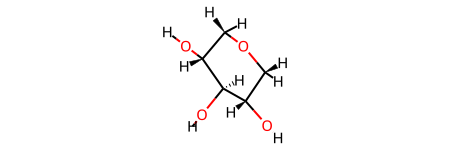

In [3]:
from rdkit import Chem
display(df.head(10))
for i ,row in df.head(1).iterrows():
    display(row["defrag"])

In [ ]:

molas = Molecules()
molas.from_dataframe(
            df=df,
            molName="defrag",
            name="InchiKey",
            fields=list(df.columns.difference(["defrag", "InchiKey"])),
            rdkit=True
        )
molas.write_sdf(f"{YOUR_PATH}/bioisosters/8hez_fragments.sdf")

In [ ]:
%load_ext autoreload
%autoreload 2

import pickle
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import PandasTools
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole

import prolif as plf
import MDAnalysis as mda
import os
IPythonConsole.ipython_useSVG = True
IPythonConsole.molSize = (400, 400)

protein = mda.Universe(f"{YOUR_PATH}/bioisosters/8hez_H.pdb") # Start from the renum version of the protein
protein = plf.Molecule.from_mda(protein)

def get_interactions_df(infile):
        infile = infile

        poses = [m for m in Chem.SDMolSupplier(infile)]
        poses = [AllChem.AddHs(m, addCoords=True) for m in poses]
        poses = [plf.Molecule.from_rdkit(m) for m in poses]
        fp = plf.Fingerprint()
        names = [m.GetProp("_Name").split(" ")[0] for m in Chem.SDMolSupplier(infile)]

        fp.run_from_iterable(poses, protein)
        df = fp.to_dataframe()
        df.columns = df.columns.droplevel()
        df.index = names
        return df


dataframes =  {}

infile = f"{YOUR_PATH}/bioisosters/8hez_fragments.sdf"
protein_name = infile.split("/")[-1].split(".")[0]
print(protein_name)
df_interactions = get_interactions_df(infile=infile)
display(df_interactions)


In [ ]:
is_hydrophobic = df_interactions.columns.get_level_values(1) == 'Hydrophobic'
interaction_df_polar = df_interactions.loc[:, ~is_hydrophobic]
display(df_interactions)
display(interaction_df_polar)

protein                         ASN75.A                        GLY79.A  \
interaction                 Hydrophobic HBDonor HBAcceptor Hydrophobic   
QXAMTEJJAZOINB-SCDXWVJYSA-N       False   False       True       False   
VZWOXDYRBDIHMA-UHFFFAOYSA-N       False   False      False       False   
DEDYPYDUBOPODQ-XCVCLJGOSA-N       False   False      False        True   
YLQBMQCUIZJEEH-UHFFFAOYSA-N       False   False      False       False   
QWJBUUQYJWNZIV-UHFFFAOYSA-N       False   False      False        True   
...                                 ...     ...        ...         ...   
JCQMGSFTMQWFPE-UHFFFAOYSA-N       False   False      False        True   
QIXXMVKHWMDVDM-UHFFFAOYSA-N       False   False      False        True   
BYSCSQXZDGQGFX-PMOUVXMZSA-N       False    True       True        True   
ZUEUIVHAINYXSJ-RFQIPJPRSA-N       False    True       True        True   
SPGCKECXUANRLJ-UHFFFAOYSA-N       False   False      False        True   

protein                         HIS80.A                GLY83.A     LEU84.A  \
interaction                 Hydrophobic PiStacking Hydrophobic Hydrophobic   
QXAMTEJJAZOINB-SCDXWVJYSA-N       False      False       False       False   
VZWOXDYRBDIHMA-UHFFFAOYSA-N        True      False        True        True   
DEDYPYDUBOPODQ-XCVCLJGOSA-N        True       True        True        True   
YLQBMQCUIZJEEH-UHFFFAOYSA-N       False      False       False       False   
QWJBUUQYJWNZIV-UHFFFAOYSA-N        True       True        True        True   
...                                 ...        ...         ...         ...   
JCQMGSFTMQWFPE-UHFFFAOYSA-N        True       True       False       False   
QIXXMVKHWMDVDM-UHFFFAOYSA-N        True       True        True        True   
BYSCSQXZDGQGFX-PMOUVXMZSA-N        True       True       False        True   
ZUEUIVHAINYXSJ-RFQIPJPRSA-N        True       True       False       False   
SPGCKECXUANRLJ-UHFFFAOYSA-N        True       True        True        True   

protein                         THR87.A          ...    PHE453.A             \
interaction                 Hydrophobic HBDonor  ... Hydrophobic PiStacking   
QXAMTEJJAZOINB-SCDXWVJYSA-N       False   False  ...       False      False   
VZWOXDYRBDIHMA-UHFFFAOYSA-N       False   False  ...        True      False   
DEDYPYDUBOPODQ-XCVCLJGOSA-N        True   False  ...        True      False   
YLQBMQCUIZJEEH-UHFFFAOYSA-N        True   False  ...        True      False   
QWJBUUQYJWNZIV-UHFFFAOYSA-N       False   False  ...        True      False   
...                                 ...     ...  ...         ...        ...   
JCQMGSFTMQWFPE-UHFFFAOYSA-N       False   False  ...        True      False   
QIXXMVKHWMDVDM-UHFFFAOYSA-N        True   False  ...        True       True   
BYSCSQXZDGQGFX-PMOUVXMZSA-N       False   False  ...        True      False   
ZUEUIVHAINYXSJ-RFQIPJPRSA-N       False   False  ...        True      False   
SPGCKECXUANRLJ-UHFFFAOYSA-N        True   False  ...        True      False   

protein                        ASP454.A    ILE456.A    GLN457.A          \
interaction                 Hydrophobic Hydrophobic Hydrophobic HBDonor   
QXAMTEJJAZOINB-SCDXWVJYSA-N       False       False       False   False   
VZWOXDYRBDIHMA-UHFFFAOYSA-N       False       False        True   False   
DEDYPYDUBOPODQ-XCVCLJGOSA-N        True       False        True   False   
YLQBMQCUIZJEEH-UHFFFAOYSA-N        True       False        True   False   
QWJBUUQYJWNZIV-UHFFFAOYSA-N       False       False        True   False   
...                                 ...         ...         ...     ...   
JCQMGSFTMQWFPE-UHFFFAOYSA-N       False        True        True   False   
QIXXMVKHWMDVDM-UHFFFAOYSA-N       False        True        True   False   
BYSCSQXZDGQGFX-PMOUVXMZSA-N       False        True        True   False   
ZUEUIVHAINYXSJ-RFQIPJPRSA-N       False        True        True   False   
SPGCKECXUANRLJ-UHFFFAOYSA-N       False        True        True   False   

protein           

protein                     ASN75.A               HIS80.A THR87.A PHE98.A  \
interaction                 HBDonor HBAcceptor PiStacking HBDonor HBDonor   
QXAMTEJJAZOINB-SCDXWVJYSA-N   False       True      False   False    True   
VZWOXDYRBDIHMA-UHFFFAOYSA-N   False      False      False   False   False   
DEDYPYDUBOPODQ-XCVCLJGOSA-N   False      False       True   False   False   
YLQBMQCUIZJEEH-UHFFFAOYSA-N   False      False      False   False   False   
QWJBUUQYJWNZIV-UHFFFAOYSA-N   False      False       True   False   False   
...                             ...        ...        ...     ...     ...   
JCQMGSFTMQWFPE-UHFFFAOYSA-N   False      False       True   False   False   
QIXXMVKHWMDVDM-UHFFFAOYSA-N   False      False       True   False   False   
BYSCSQXZDGQGFX-PMOUVXMZSA-N    True       True       True   False   False   
ZUEUIVHAINYXSJ-RFQIPJPRSA-N    True       True       True   False   False   
SPGCKECXUANRLJ-UHFFFAOYSA-N   False      False       True   False   False   

protein                                GLU99.A SER287.A              TYR290.A  \
interaction                 PiStacking HBDonor  HBDonor HBAcceptor PiStacking   
QXAMTEJJAZOINB-SCDXWVJYSA-N      False   False     True       True      False   
VZWOXDYRBDIHMA-UHFFFAOYSA-N       True   False    False      False      False   
DEDYPYDUBOPODQ-XCVCLJGOSA-N       True   False    False      False      False   
YLQBMQCUIZJEEH-UHFFFAOYSA-N       True   False    False      False      False   
QWJBUUQYJWNZIV-UHFFFAOYSA-N       True   False    False      False      False   
...                                ...     ...      ...        ...        ...   
JCQMGSFTMQWFPE-UHFFFAOYSA-N      False   False    False      False      False   
QIXXMVKHWMDVDM-UHFFFAOYSA-N       True   False    False      False      False   
BYSCSQXZDGQGFX-PMOUVXMZSA-N      False    True     True       True      False   
ZUEUIVHAINYXSJ-RFQIPJPRSA-N      False    True     True       True      False   
SPGCKECXUANRLJ-UHFFFAOYSA-N      False   False    False      False      False   

protein                       LYS321.A   PHE453.A GLN457.A             \
interaction                 HBAcceptor PiStacking  HBDonor HBAcceptor   
QXAMTEJJAZOINB-SCDXWVJYSA-N       True      False    False       True   
VZWOXDYRBDIHMA-UHFFFAOYSA-N      False      False    False      False   
DEDYPYDUBOPODQ-XCVCLJGOSA-N      False      False    False      False   
YLQBMQCUIZJEEH-UHFFFAOYSA-N      False      False    False      False   
QWJBUUQYJWNZIV-UHFFFAOYSA-N      False      False    False      False   
...                                ...        ...      ...        ...   
JCQMGSFTMQWFPE-UHFFFAOYSA-N      False      False    False      False   
QIXXMVKHWMDVDM-UHFFFAOYSA-N      False       True    False      False   
BYSCSQXZDGQGFX-PMOUVXMZSA-N      False      False    False       True   
ZUEUIVHAINYXSJ-RFQIPJPRSA-N      False      False    False       True   
SPGCKECXUANRLJ-UHFFFAOYSA-N      False      False    False      False   

protein                       TYR526.A  
interaction                 PiStacking  
QXAMTEJJAZOINB-SCDXWVJYSA-N      False  
VZWOXDYRBDIHMA-UHFFFAOYSA-N      False  
DEDYPYDUBOPODQ-XCVCLJGOSA-N      False  
YLQBMQCUIZJEEH-UHFFFAOYSA-N      False  
QWJBUUQYJWNZIV-UHFFFAOYSA-N      False  
...                                ...  
JCQMGSFTMQWFPE-UHFFFAOYSA-N      False  
QIXXMVKHWMDVDM-UHFFFAOYSA-N      False  
BYSCSQXZDGQGFX-PMOUVXMZSA-N      False  
ZUEUIVHAINYXSJ-RFQIPJPRSA-N      False  
SPGCKECXUANRLJ-UHFFFAOYSA-N      False  

[589 rows x 15 columns]

In [ ]:
target_row = interaction_df_polar.loc['NUXARLNUETVYNJ-YTWAJWBKSA-N']

is_duplicate = interaction_df_polar.eq(target_row).all(axis=1)

subset_df = interaction_df_polar[is_duplicate]

display(subset_df)

In [ ]:
inchikey_list = subset_df.index.tolist()
print(inchikey_list)

In [ ]:
mols = Molecules(infile=f"{YOUR_PATH}/bioisosters/8hez_fragments.sdf", read = True)
df = mols.dataframe()
display(df)

,_Name,_MolFileInfo,_MolFileComments,BindingDB_Compound_id,CHEMBL_Compound_id,confidence_score,exp_activity,id,index,ligand_inchikey,pdb,uniprot,mol
0,QXAMTEJJAZOINB-SCDXWVJYSA-N,RDKit 3D,,BDBM50337088,CHEMBL1672816,0.6465059917516454,8.6,5564,0,PVMGWXZGRHEODP-FTWQHDNSSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0d924da110>
1,VZWOXDYRBDIHMA-UHFFFAOYSA-N,RDKit 3D,,BDBM50333635,CHEMBL1642516,0.6292609157702924,8.0,5571,1,RVEQZNWBFLPFSQ-GFEQUFNTSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0d924da1f0>
2,DEDYPYDUBOPODQ-XCVCLJGOSA-N,RDKit 3D,,BDBM50337051,CHEMBL1672779,0.6348616704399477,8.3,5586,2,SHPLXKFUHIGDKW-SOWNGPAHSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0d924d9ee0>
3,YLQBMQCUIZJEEH-UHFFFAOYSA-N,RDKit 3D,,BDBM50333635,CHEMBL1642516,0.6292609157702924,8.0,5842,3,RVEQZNWBFLPFSQ-GFEQUFNTSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0d924da180>
4,QWJBUUQYJWNZIV-UHFFFAOYSA-N,RDKit 3D,,BDBM50333635,CHEMBL1642516,0.6292609157702924,8.0,5923,4,RVEQZNWBFLPFSQ-GFEQUFNTSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0d924da260>
...,...,...,...,...,...,...,...,...,...,...,...,...,...
584,JCQMGSFTMQWFPE-UHFFFAOYSA-N,RDKit 3D,,BDBM159389,CHEMBL3703787,0.6649682000725362,9.1,797194,1808,HELMTEKXBFJGTB-SMQFJCFBSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0dd00c1c40>
585,QIXXMVKHWMDVDM-UHFFFAOYSA-N,RDKit 3D,,BDBM159389,CHEMBL3703787,0.6649682000725362,9.1,797670,1810,HELMTEKXBFJGTB-SMQFJCFBSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0dd00c1cb0>
586,BYSCSQXZDGQGFX-PMOUVXMZSA-N,RDKit 3D,,BDBM159391,CHEMBL3703789,0.6801457036231892,9.2,800553,1816,UOOBZXBFTKWEMJ-LKZJFHPWSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0dd00c1d20>
587,ZUEUIVHAINYXSJ-RFQIPJPRSA-N,RDKit 3D,,BDBM159391,CHEMBL3703789,0.6801457036231892,9.2,800841,1817,UOOBZXBFTKWEMJ-LKZJFHPWSA-N,8hez,P31639,<rdkit.Chem.rdchem.Mol object at 0x7d0dd00c1d90>


In [ ]:
inchikey_list = ['NUXARLNUETVYNJ-YTWAJWBKSA-N', 'XBGAVZKMCZLVNU-KXNHARMFSA-N', 'PGAZPNLJJSACKR-BARDWOONSA-N', 'ZXXUHEQPVIJGFQ-QXSJWSMHSA-N',
                 'MDHUTAQEODUTHW-XAVMHZPKSA-N', 'TZPUWRDLEZMSPO-RGOKHQFPSA-N', 'DHWGSBAHGTYCBU-RQJABVFESA-N', 'QUMUQPIUGKSVNZ-BARDWOONSA-N',
                 'DNSNMDAKWQPPOP-KXNHARMFSA-N', 'ZGMGOCUWEUPUDN-XQHKEYJVSA-N', 'QMHPKPQBRJDGIB-MGAJPHDKSA-N', 'DGYIDPCLXKWLJJ-KLHWPWHYSA-N',
                 'WGARZMVJGQQWLI-RGDJUOJXSA-N', 'FRSIGYOMJIQZSJ-LBELIVKGSA-N', 'DWLVXCKDOYOFKW-WYUUTHIRSA-N', 'NSHXFOFSRYPNSP-HCLZXYDTSA-N',
                 'YCZAOMSLCZJBNC-JPXBYFMYSA-N', 'ODSVFNJBNBFHOV-LBELIVKGSA-N', 'ZNICBPALSLLUGH-YTWAJWBKSA-N', 'UOGMQTBEBUKBIO-KXNHARMFSA-N',
                 'JBSXOXFGROESJT-MGAJPHDKSA-N', 'LJAYHPUJMHWXPQ-KXNHARMFSA-N', 'ZVICXFQCFJZIQY-KXNHARMFSA-N', 'BTJOIQGLPKXWQW-YTWAJWBKSA-N',
                 'QZSXJRQVIKJVMD-XQHKEYJVSA-N', 'REJXCQOIGDYHHK-KXNHARMFSA-N', 'MXBZPIFPBYRNPM-CABNGKKXSA-N', 'DIULJAACMACQDK-YTWAJWBKSA-N',
                 'ZWDNOWXNFLWWOK-KXNHARMFSA-N', 'LAEIFVBOGKQMAW-MGAJPHDKSA-N', 'GHOUNCZYROOETG-CABNGKKXSA-N', 'WGXZCXLYJTTZCH-XZUYRWCXSA-N',
                 'DOIOZCXYYXLWAD-RQJABVFESA-N', 'KBORVSIPTRHSBP-XQHKEYJVSA-N', 'SDCWPABPSUUDGN-UVOCVTCTSA-N', 'BXRFKWUWQWQYGO-RGOKHQFPSA-N',
                 'HJIVUNCRYSNDOS-XAVMHZPKSA-N', 'BZTDFWSXGWJHGB-RQJABVFESA-N', 'BLHKEJQACBRTII-BARDWOONSA-N', 'BYSCSQXZDGQGFX-BEAPCOKYSA-N',
                 'ZUEUIVHAINYXSJ-RQJABVFESA-N', 'NTJHHRLRZUKYCZ-BARDWOONSA-N', 'PYUHAZLFOPHRPZ-TWMKSMIVSA-N', 'ZSHLHDLKAAJNFK-RQJABVFESA-N',
                 'FMGUMTYUIJYESU-TWMKSMIVSA-N', 'CMBOCZVTGOLKJT-QXSJWSMHSA-N', 'FZKJCLPMOHFYTE-GCHJQGSQSA-N', 'BWKGOJKYNNCSTE-BNDIWNMDSA-N',
                 'MOUJOUPAFRBQGD-XZUYRWCXSA-N', 'BNUIUDZKSWXMJT-KLBPJQLPSA-N']


In [ ]:
mols = Molecules(infile=f"{ZENODO_PATH}/SAFR_v1.0.1/P31639/8hez.sdf")
df = mols.dataframe()

df = df.drop_duplicates(subset=["InchiKey"])
df= df.reset_index()
df["id"] = df["_Name"]
df.drop('_Name', axis = 1, inplace = True)


df_bioisosters = df[df["InchiKey"].isin(inchikey_list)]
df_bioisosters["_Name"] = df["InchiKey"]
display(df_bioisosters)

/tmp/ipykernel_126576/1751433067.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_bioisosters["_Name"] = df["InchiKey"]


,index,_MolFileInfo,_MolFileComments,InchiKey,confidence_score,exp_activity,ligand_inchikey,pdb,uniprot,BindingDB_Compound_id,CHEMBL_Compound_id,mol,id,_Name
6,6,RDKit 3D,,NUXARLNUETVYNJ-YTWAJWBKSA-N,0.6465059917516454,8.6,PVMGWXZGRHEODP-FTWQHDNSSA-N,8hez,P31639,BDBM50337088,CHEMBL1672816,<rdkit.Chem.rdchem.Mol object at 0x7d0d902534c0>,6077,NUXARLNUETVYNJ-YTWAJWBKSA-N
19,21,RDKit 3D,,XBGAVZKMCZLVNU-KXNHARMFSA-N,0.6465059917516454,8.6,PVMGWXZGRHEODP-FTWQHDNSSA-N,8hez,P31639,BDBM50337088,CHEMBL1672816,<rdkit.Chem.rdchem.Mol object at 0x7d0d90247ca0>,6817,XBGAVZKMCZLVNU-KXNHARMFSA-N
29,38,RDKit 3D,,ZVICXFQCFJZIQY-KXNHARMFSA-N,0.6584437598585993,6.2,PNMHKVIHICBNQB-ADAARDCZSA-N,8hez,P31639,BDBM50381545,CHEMBL2018085,<rdkit.Chem.rdchem.Mol object at 0x7d0d902545f0>,8296,ZVICXFQCFJZIQY-KXNHARMFSA-N
33,45,RDKit 3D,,BTJOIQGLPKXWQW-YTWAJWBKSA-N,0.6584437598585993,6.2,PNMHKVIHICBNQB-ADAARDCZSA-N,8hez,P31639,BDBM50381545,CHEMBL2018085,<rdkit.Chem.rdchem.Mol object at 0x7d0d90254190>,8494,BTJOIQGLPKXWQW-YTWAJWBKSA-N
36,50,RDKit 3D,,SDCWPABPSUUDGN-UVOCVTCTSA-N,0.6292609157702924,8.0,RVEQZNWBFLPFSQ-GFEQUFNTSA-N,8hez,P31639,BDBM50333635,CHEMBL1642516,<rdkit.Chem.rdchem.Mol object at 0x7d0d90254200>,9037,SDCWPABPSUUDGN-UVOCVTCTSA-N
38,52,RDKit 3D,,NTJHHRLRZUKYCZ-BARDWOONSA-N,0.6277079317672768,7.4,POVOMCJBEWWPBK-DFLSAPQXSA-N,8hez,P31639,BDBM458098,CHEMBL5989707,<rdkit.Chem.rdchem.Mol object at 0x7d0d90256500>,28045,NTJHHRLRZUKYCZ-BARDWOONSA-N
39,53,RDKit 3D,,ZSHLHDLKAAJNFK-RQJABVFESA-N,0.6277079317672768,7.4,POVOMCJBEWWPBK-DFLSAPQXSA-N,8hez,P31639,BDBM458098,CHEMBL5989707,<rdkit.Chem.rdchem.Mol object at 0x7d0d90254580>,28080,ZSHLHDLKAAJNFK-RQJABVFESA-N
41,59,RDKit 3D,,DHWGSBAHGTYCBU-RQJABVFESA-N,0.6988798560959336,8.1,BJTWZDIWFBFQEH-SJSRKZJXSA-N,8hez,P31639,BDBM159388,CHEMBL3703786,<rdkit.Chem.rdchem.Mol object at 0x7d0d90256d50>,28392,DHWGSBAHGTYCBU-RQJABVFESA-N
76,121,RDKit 3D,,QUMUQPIUGKSVNZ-BARDWOONSA-N,0.6988798560959336,8.1,BJTWZDIWFBFQEH-SJSRKZJXSA-N,8hez,P31639,BDBM159388,CHEMBL3703786,<rdkit.Chem.rdchem.Mol object at 0x7d0d90259620>,30966,QUMUQPIUGKSVNZ-BARDWOONSA-N
81,129,RDKit 3D,,FRSIGYOMJIQZSJ-LBELIVKGSA-N,0.6473412832796563,6.7,VMBBVZIQQGSIKZ-SFFUCWETSA-N,8hez,P31639,BDBM50331222,CHEMBL1289398,<rdkit.Chem.rdchem.Mol object at 0x7d0d90259000>,58448,FRSIGYOMJIQZSJ-LBELIVKGSA-N


In [ ]:
writer = Chem.SDWriter(f"{YOUR_PATH}/bioisosters/8hez_bioisosters.sdf")

for index, row in df_bioisosters.iterrows():
    mol = row['mol']
    if mol:
        for col in df_bioisosters.columns:
            if col != 'mol':
                mol.SetProp(col, str(row[col]))
        writer.write(mol)

writer.close()


In [ ]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdFMCS
from rdkit.DataStructs import BulkTanimotoSimilarity
from rdkit.ML.Cluster import Butina
from rdkit.Chem import Draw

mols = Molecules(f"{YOUR_PATH}/bioisosters/8hez_bioisosters.sdf")
df = mols.dataframe()


df['fingerprint'] = df['mol'].apply(lambda x: AllChem.GetMorganFingerprintAsBitVect(x, 2, nBits=2048))

df["mol"] = df["mol"].apply(lambda x: Chem.MolFromSmiles(Chem.MolToSmiles(x)))


fps = df['fingerprint'].tolist()
n_mols = len(fps)

dist_mat = []
for i in range(1, n_mols):
    sims = BulkTanimotoSimilarity(fps[i], fps[:i])
    dist_mat.extend([1 - x for x in sims])

clusters = Butina.ClusterData(dist_mat, n_mols, 0.3, isDistData=True)
diverse_indices = [c[0] for c in clusters][:25]
diverse_mols = [df.iloc[i]['mol'] for i in diverse_indices]
legends = [df.iloc[i]['CHEMBL_Compound_id'] for i in diverse_indices]


for mol in diverse_mols:
    for atom in mol.GetAtoms():

        if atom.GetSymbol() == '*':

            atom.SetProp("atomLabel", "R")



ref_mol = Chem.MolFromSmiles("C1CCC(OC1)C1=CC=CC=C1")
AllChem.Compute2DCoords(ref_mol)

for i, mol in enumerate(diverse_mols):
    if i == 0:
        continue
    try:
        mcs = rdFMCS.FindMCS([ref_mol, mol])
        if mcs.numAtoms > 0:
            patt = Chem.MolFromSmarts(mcs.smartsString)
            AllChem.GenerateDepictionMatching2DStructure(patt, ref_mol)
            AllChem.GenerateDepictionMatching2DStructure(mol, patt)
        else:
            AllChem.Compute2DCoords(mol)
    except (ValueError, RuntimeError):
        AllChem.Compute2DCoords(mol)


draw_opts = Draw.MolDrawOptions()
draw_opts.useBWAtomPalette()
draw_opts.bondLineWidth = 3
draw_opts.minFontSize = 15


img = Draw.MolsToGridImage(
    diverse_mols,
    molsPerRow=5,
    subImgSize=(200, 200),
    drawOptions=draw_opts,
    legends=legends,
    returnPNG=False
)

img.save(f"{YOUR_PATH}/bioisosters/8hez_bioisosters_grid.png", dpi = (600,600))